## pair work #3 exercises 4.1 and 4.3
josh and matt

In [6]:
#problem 4.1
import numpy as np

fact_list = [1]
factorial = 1
n = 170 #factorial number
for z in range(2, n+1):
    fact_list.append(z)
for k in (fact_list):
    factorial *= k
print(factorial)

7257415615307998967396728211129263114716991681296451376543577798900561843401706157852350749242617459511490991237838520776666022565442753025328900773207510902400430280058295603966612599658257104398558294257568966313439612262571094946806711205568880457193340212661452800000000000000000000000000000000000000000


In [7]:
#for the int its pretty damned accurate but for float it gives infity
import numpy as np

fact_list = [1]
factorial = 1.000
n = 200 #factorial number
for z in range(2, n+1):
    fact_list.append(z)
for k in (fact_list):
    factorial *= k
print(factorial)

inf


This makes sense as the biggest number for a float can only be 10^(308) and the number we supposedly get is 7....*10^(374).

In [8]:
#problem 4.3
import numpy as np
def function(h, x):
    return (x+h)*((x+h)-1)
x = 1
h = 1/100
deriv = (function(h, x) - ((x)*(x-1)))/h
print(deriv)

1.010000000000001


After calculating the real value of this number when taking the derivative using power rule after distributing should be 1, these are off because the derivative goes to the limit as it goes to zero. this isnt anywhere near 0.

In [59]:
#problem 4.3
import numpy as np
import math
def function(x):
    return (x*(x-1))
x = 1
for g in range(2, 20,2):
    h = 1/(10**g)
    deriv = (function(x+h) - function(x))/h
    print("h = ",h,"| df/dx =", deriv)


h =  0.01 | df/dx = 1.010000000000001
h =  0.0001 | df/dx = 1.0000999999998899
h =  1e-06 | df/dx = 1.0000009999177333
h =  1e-08 | df/dx = 1.0000000039225287
h =  1e-10 | df/dx = 1.000000082840371
h =  1e-12 | df/dx = 1.0000889005833413
h =  1e-14 | df/dx = 0.9992007221626509
h =  1e-16 | df/dx = 0.0
h =  1e-18 | df/dx = 0.0


the reason why it gets worse is because as you go to 10^-8 power we start rounding out numbers. As we get to 10^-16 the function(x+h) becomes identical to function(x)

In [9]:
#problem 5.15
import numpy as np
import matplotlib.pyplot as plt
import math

def function(x):
    return(1 + 0.5 * np.tanh(2*x))

x = 2
for g in range(2,20,2):
    h = 1/(10**g)
    deriv = (function(x+h) - function(x-h))/(2*h)
    
    print("h = ",h,"| df/dx =", deriv)


h =  0.01 | df/dx = 0.0013413075789392437
h =  0.0001 | df/dx = 0.001340950718242695
h =  1e-06 | df/dx = 0.0013409506838257812
h =  1e-08 | df/dx = 0.0013409495736027566
h =  1e-10 | df/dx = 0.001341149413747189
h =  1e-12 | df/dx = 0.0013322676295501878
h =  1e-14 | df/dx = 0.0
h =  1e-16 | df/dx = 0.0
h =  1e-18 | df/dx = 0.0


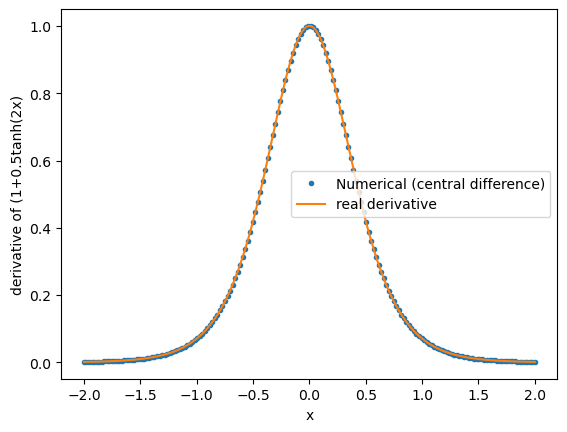

In [32]:
#now we know we actually get the numerical derivative using the central distance and the best h value is 10**6
#i calculated the derivative using wolfram alpha to get sech^2(2*h) but numpy doesnt have sech only cosh so use 1/cosh

#problem 5.15
import numpy as np
import matplotlib.pyplot as plt
import math

def function(x):
    return(1 + 0.5 * np.tanh(2*x))

def real_deriv(x):
    return(1 / (np.cosh(2*x))**2)

x = np.linspace(-2, 2, 180)
x_s = np.linspace(-2, 2, 3000)
h = 10**(-7)

num_deriv = (function(x+h) - function(x-h))/(2*h)

plt.plot(x,num_deriv, '.', label="Numerical (central difference)")
plt.plot(x_s, real_deriv(x_s), label="real derivative")
plt.legend()
plt.xlabel("x")
plt.ylabel("derivative of (1+0.5tanh(2x)")
plt.show()

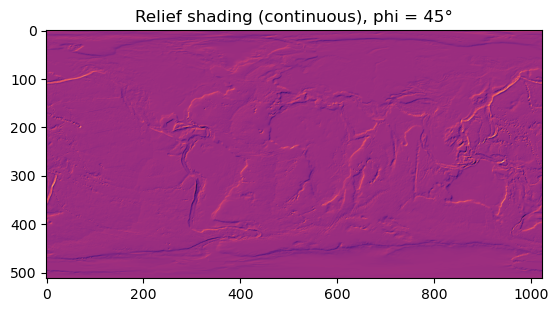

In [97]:
#problem 5.
import numpy as np
import matplotlib.pyplot as plt

altitude = 'altitude.txt'
f = np.loadtxt(altitude)

h = 30000
ny, nx = f.shape
dfdx = np.zeros(f.shape)
dfdy = np.zeros(f.shape)

for i in range(ny):
    for j in range(1, nx-1):
        dfdx[i, j] = (f[i, j+1] - f[i, j-1]) / (2*h)
    dfdy[i, 0]  = (f[i, 1] - f[i, 0]) / h
    dfdy[i, -1] = (f[i, -1] - f[i, -2]) / h

for i in range(1, ny-1):
    for j in range(nx):
        dfdy[i, j] = (f[i+1, j] - f[i-1, j]) / (2*h)
    dfdy[0, j]  = (f[1, j] - f[0, j]) / h
    dfdy[-1, j] = (f[-1, j] - f[-2, j]) / h

phi = np.deg2rad(45.0)

n = -(np.cos(phi) * dfdy + np.sin(phi) * dfdx)
d = np.sqrt(dfdx**2 + dfdy**2 + 1.0)
I = n / d  



plt.figure()
plt.imshow(I, cmap="magma")

plt.title("Relief shading (continuous), phi = 45°")
plt.show()



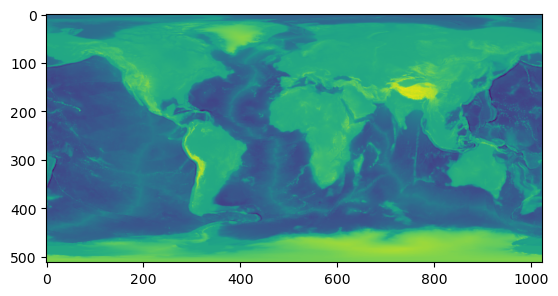

In [ ]:
plt.imshow(f)

In [81]:
print(n)
print(d)

[[-3.01698893e-05 -2.58093975e-05 -2.06239478e-05 ... -6.38753126e-05
  -5.72756493e-05 -3.23902046e-03]
 [-1.72440952e-02 -1.75178634e-02 -1.74805046e-02 ... -1.68561293e-02
  -1.71515821e-02 -1.70987848e-02]
 [-2.45792674e-02 -2.42443345e-02 -2.36738172e-02 ... -2.51395317e-02
  -2.52232060e-02 -2.47053681e-02]
 ...
 [ 1.98473088e-03  2.01926126e-03  2.01584358e-03 ...  2.02574308e-03
   2.02645018e-03  1.98720576e-03]
 [ 2.30811438e-03  2.31176777e-03  2.29432580e-03 ...  2.38507117e-03
   2.36880772e-03  2.32614561e-03]
 [ 2.12132034e-06  2.00346921e-06  1.53206469e-06 ...  1.17851130e-06
   2.12132034e-06  2.65754299e-03]]
[[1.         1.         1.         ... 1.         1.         1.00001049]
 [1.00029731 1.00029884 1.00029809 ... 1.00027331 1.00028355 1.00029233]
 [1.00060396 1.00058534 1.00056281 ... 1.00059839 1.00060524 1.00061017]
 ...
 [1.00000394 1.00000392 1.00000391 ... 1.00000396 1.00000396 1.00000395]
 [1.00000533 1.00000525 1.00000516 ... 1.00000558 1.0000055  1.0000